# SHAP: quali angoli guidano la classificazione?

Nessun numero qui e' scritto a mano: tutto viene da `results/shap_rehab24_anatomical.csv`, prodotto da `python src/run_shap.py --all`. Per ogni esercizio, quel runner prende il modello che ha vinto sulla famiglia `anatomical` in `results/experiments.csv` (letto, non deciso a mano), lo rispiega con permutation SHAP (stesso codice per logreg/rf/mlp) usando split raggruppati per soggetto ripetuti 5 volte - ogni campione e' spiegato solo da modelli che non lo hanno mai visto in training, la stessa regola anti-leakage della CV principale.

Domanda a cui questa analisi risponde: le feature anatomiche (angoli con nome) sono l'unica famiglia interpretabile del progetto - ma quali angoli specifici guidano davvero la decisione, esercizio per esercizio? E coincidono con l'intuizione clinica (es. valgismo del ginocchio negli squat)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

pd.set_option("display.width", 160)

df = pd.read_csv("../results/shap_rehab24_anatomical.csv")
shap_cols = [c for c in df.columns if c.startswith("shap__")]
feature_names = [c[len("shap__"):] for c in shap_cols]
value_cols = [f"value__{f}" for f in feature_names]

print(f"{df.shape[0]} campioni spiegati, {len(feature_names)} feature, esercizi: {sorted(df['exercise'].unique())}")
print(df[["exercise", "model"]].drop_duplicates().to_string(index=False))

594 campioni spiegati, 86 feature, esercizi: ['Ex1', 'Ex2', 'Ex3', 'Ex4', 'Ex5', 'Ex6']
exercise  model
     Ex1 logreg
     Ex2     rf
     Ex3 logreg
     Ex4    mlp
     Ex5     rf
     Ex6 logreg


## Ranking globale: quali feature contano di piu', in media su tutti gli esercizi?

trunk_flex_mean                 0.0155
trunk_flex_max                  0.0150
trunk_flex_min                  0.0143
r_ankle_vel_mean_abs            0.0140
l_ankle_min                     0.0122
l_ankle_vel_mean_abs            0.0118
r_shoulder_angle_max            0.0117
l_knee_vel_mean_abs             0.0111
r_hip_max                       0.0109
l_shoulder_angle_min            0.0109
l_shoulder_angle_rom            0.0108
l_shoulder_angle_std            0.0106
r_ankle_mean                    0.0106
l_hip_max                       0.0106
r_shoulder_angle_mean           0.0105
r_hip_vel_mean_abs              0.0105
l_shoulder_angle_vel_mean_abs   0.0105
l_knee_mean                     0.0105
r_ankle_vel_max_abs             0.0104
knee_valgus_min                 0.0102


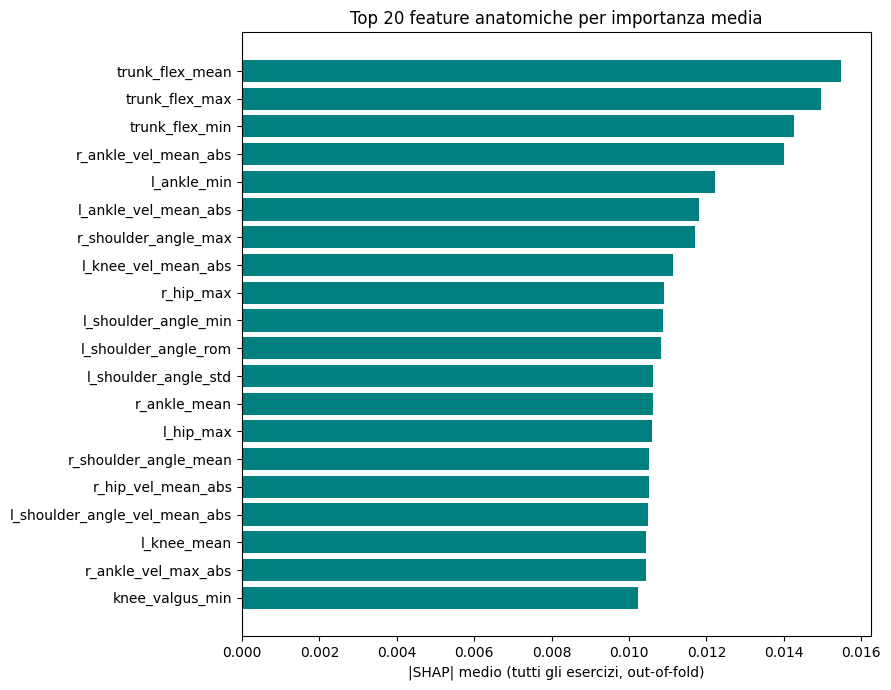

In [2]:
mean_abs_shap = df[shap_cols].abs().mean().sort_values(ascending=False)
mean_abs_shap.index = [i[len("shap__"):] for i in mean_abs_shap.index]

print(mean_abs_shap.head(20).to_string(float_format="%.4f"))

fig, ax = plt.subplots(figsize=(9, 7))
top20 = mean_abs_shap.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color="teal")
ax.set_xlabel("|SHAP| medio (tutti gli esercizi, out-of-fold)")
ax.set_title("Top 20 feature anatomiche per importanza media")
plt.tight_layout()
plt.show()

## Per esercizio: bar chart di importanza + beeswarm

Il bar chart mostra |SHAP| medio (quanto una feature sposta la predizione, in media, indipendentemente dalla direzione). Il beeswarm aggiunge la direzione: ogni punto e' un campione, colore=valore della feature (rosso=alto, blu=basso), posizione orizzontale=impatto SHAP sulla probabilita' di 'corretto'.


Ex1 (modello: logreg, n=88) - top 12 feature:
              feature  mean_abs_shap
 r_elbow_vel_mean_abs         0.0156
            r_hip_max         0.0155
            l_hip_std         0.0154
  r_elbow_vel_max_abs         0.0148
 r_shoulder_angle_std         0.0143
       trunk_flex_max         0.0138
           r_hip_mean         0.0126
            r_hip_min         0.0122
             sym_knee         0.0121
            l_hip_rom         0.0119
         r_ankle_mean         0.0117
r_shoulder_angle_mean         0.0115


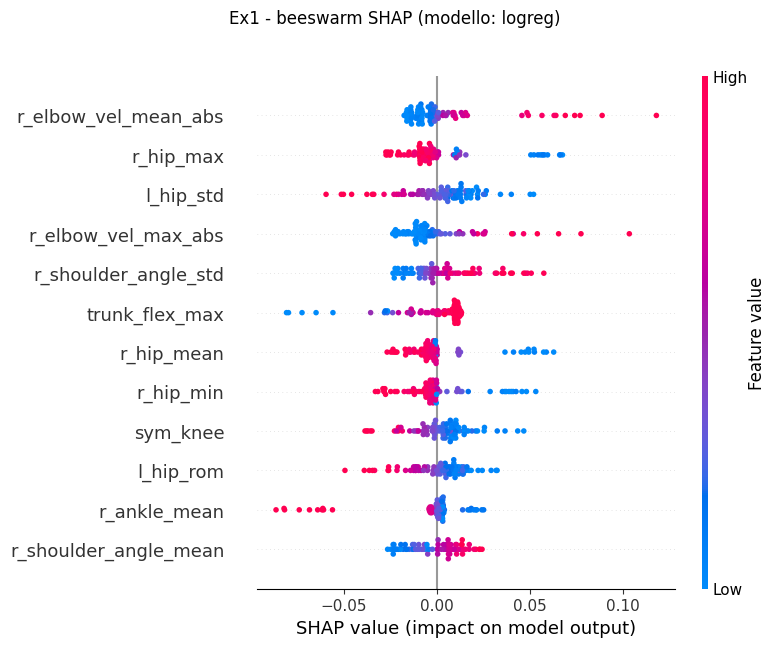


Ex2 (modello: rf, n=109) - top 12 feature:
                     feature  mean_abs_shap
        l_ankle_vel_mean_abs         0.0222
        r_ankle_vel_mean_abs         0.0208
         r_ankle_vel_max_abs         0.0204
         l_knee_vel_mean_abs         0.0204
          r_hip_vel_mean_abs         0.0184
           r_hip_vel_max_abs         0.0182
          l_hip_vel_mean_abs         0.0147
        l_shoulder_angle_rom         0.0142
     trunk_flex_vel_mean_abs         0.0137
                   r_hip_max         0.0137
l_shoulder_angle_vel_max_abs         0.0130
         r_knee_vel_mean_abs         0.0129


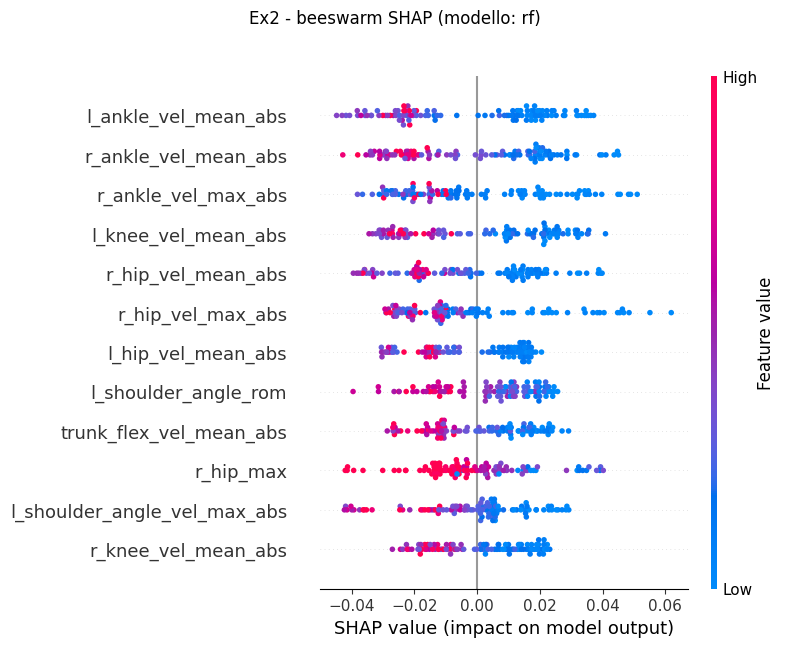


Ex3 (modello: logreg, n=107) - top 12 feature:
                     feature  mean_abs_shap
                l_elbow_mean         0.0297
                   sym_elbow         0.0282
              trunk_flex_max         0.0213
                 l_elbow_std         0.0212
             trunk_flex_mean         0.0210
         l_knee_vel_mean_abs         0.0196
                 l_elbow_min         0.0184
                   r_hip_rom         0.0183
                   r_hip_std         0.0174
        l_shoulder_angle_max         0.0169
                 l_elbow_rom         0.0168
r_shoulder_angle_vel_max_abs         0.0166


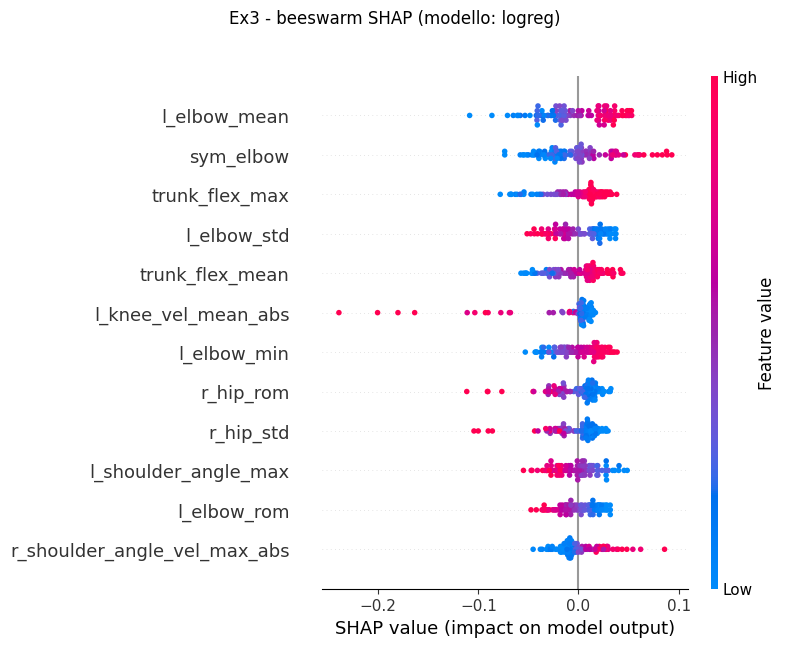


Ex4 (modello: mlp, n=116) - top 12 feature:
             feature  mean_abs_shap
     trunk_flex_mean         0.0409
r_shoulder_angle_max         0.0405
      trunk_flex_min         0.0378
           l_hip_max         0.0372
l_shoulder_angle_min         0.0346
        sym_shoulder         0.0336
      trunk_flex_max         0.0306
r_shoulder_angle_rom         0.0300
         l_elbow_max         0.0280
        r_ankle_mean         0.0247
           r_hip_max         0.0239
         r_elbow_min         0.0238


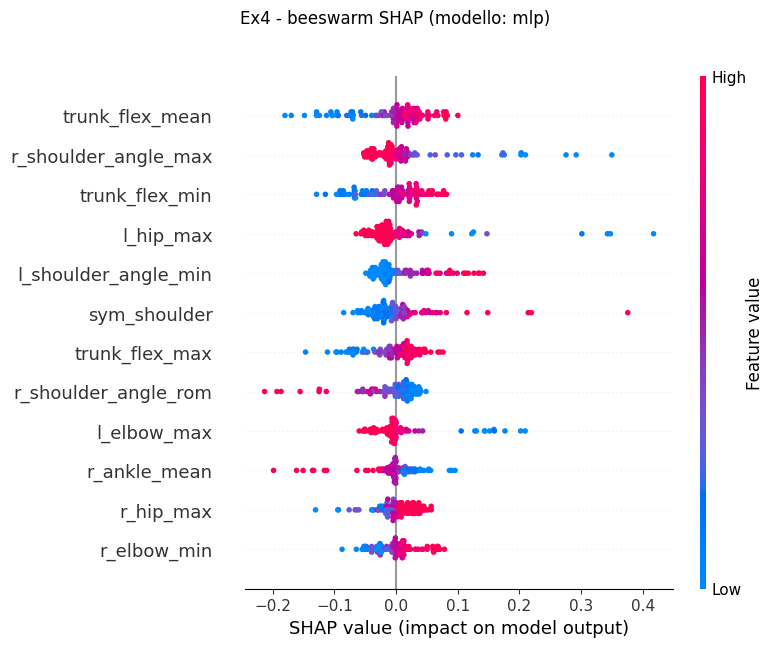


Ex5 (modello: rf, n=76) - top 12 feature:
                     feature  mean_abs_shap
        r_ankle_vel_mean_abs         0.0347
                 l_ankle_min         0.0319
         r_ankle_vel_max_abs         0.0190
                   l_hip_std         0.0188
l_shoulder_angle_vel_max_abs         0.0157
       l_shoulder_angle_mean         0.0147
                 r_ankle_rom         0.0143
                   l_hip_min         0.0127
         r_knee_vel_mean_abs         0.0124
                 l_ankle_rom         0.0123
                   l_hip_rom         0.0115
          l_hip_vel_mean_abs         0.0114


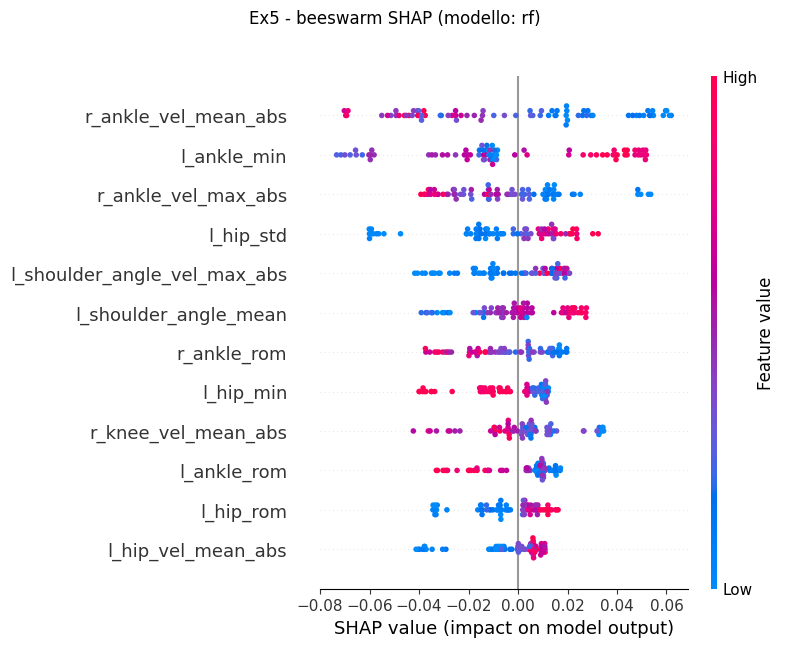


Ex6 (modello: logreg, n=98) - top 12 feature:
              feature  mean_abs_shap
      knee_valgus_min         0.0227
          l_knee_mean         0.0223
          l_ankle_min         0.0185
 r_shoulder_angle_min         0.0184
         l_ankle_mean         0.0176
r_shoulder_angle_mean         0.0172
  r_ankle_vel_max_abs         0.0142
       trunk_flex_std         0.0138
 r_ankle_vel_mean_abs         0.0133
          r_knee_mean         0.0127
          r_ankle_min         0.0122
          r_ankle_rom         0.0116


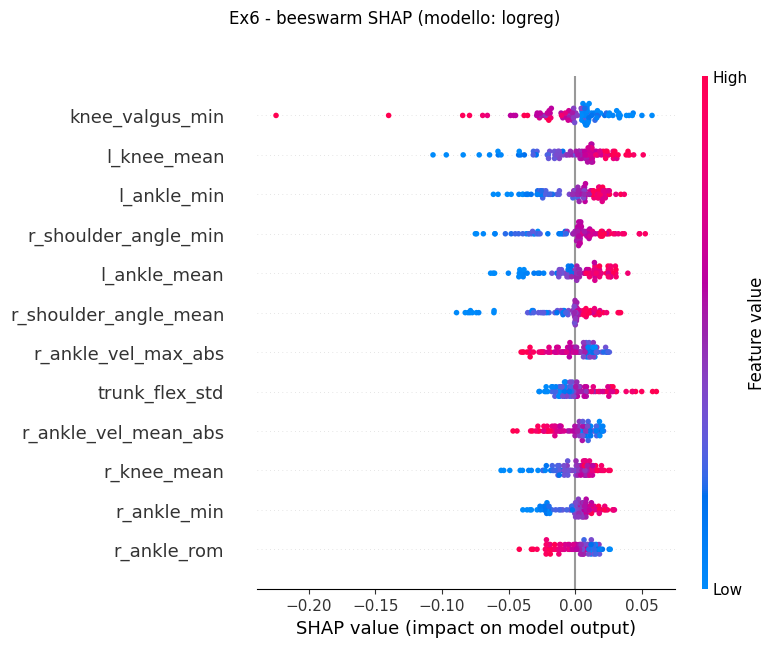

In [3]:
N_TOP = 12

for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    model_name = sub["model"].iloc[0]
    shap_vals = sub[shap_cols].values
    data_vals = sub[value_cols].values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:N_TOP]

    print(f"\n{ex} (modello: {model_name}, n={len(sub)}) - top {N_TOP} feature:")
    top_table = pd.DataFrame({"feature": np.array(feature_names)[order],
                              "mean_abs_shap": mean_abs[order]})
    print(top_table.to_string(index=False, float_format="%.4f"))

    expl = shap.Explanation(values=shap_vals[:, order], data=data_vals[:, order],
                             feature_names=list(np.array(feature_names)[order]))
    shap.plots.beeswarm(expl, max_display=N_TOP, show=False)
    fig = plt.gcf()
    fig.suptitle(f"{ex} - beeswarm SHAP (modello: {model_name})", y=1.02)
    plt.tight_layout()
    plt.show()

## Coerenza tra esercizi: le stesse feature contano ovunque o e' tutto specifico per esercizio?

In [4]:
top5_by_ex = {}
for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    mean_abs = sub[shap_cols].abs().mean()
    mean_abs.index = feature_names
    top5_by_ex[ex] = set(mean_abs.sort_values(ascending=False).head(5).index)

from collections import Counter
appearances = Counter(f for top5 in top5_by_ex.values() for f in top5)
consistency = pd.Series(appearances).sort_values(ascending=False)
print("Quante volte (su 6 esercizi) ogni feature compare nella top-5 locale:")
print(consistency.to_string())

print("\nTop-5 per esercizio:")
for ex, feats in top5_by_ex.items():
    print(f"  {ex}: {sorted(feats)}")

Quante volte (su 6 esercizi) ogni feature compare nella top-5 locale:
l_hip_std                       2
r_ankle_vel_max_abs             2
l_ankle_min                     2
trunk_flex_mean                 2
r_ankle_vel_mean_abs            2
r_hip_max                       1
r_elbow_vel_mean_abs            1
r_shoulder_angle_std            1
r_elbow_vel_max_abs             1
l_knee_vel_mean_abs             1
l_ankle_vel_mean_abs            1
r_hip_vel_mean_abs              1
trunk_flex_max                  1
l_elbow_std                     1
l_elbow_mean                    1
l_hip_max                       1
sym_elbow                       1
l_shoulder_angle_min            1
trunk_flex_min                  1
r_shoulder_angle_max            1
l_shoulder_angle_vel_max_abs    1
r_shoulder_angle_min            1
l_ankle_mean                    1
knee_valgus_min                 1
l_knee_mean                     1

Top-5 per esercizio:
  Ex1: ['l_hip_std', 'r_elbow_vel_max_abs', 'r_elbow_vel_m

## Lettura onesta

**Coincide con l'intuizione clinica?** Su Ex6 (squat) si', in modo diretto: `knee_valgus_min` - la feature costruita apposta per catturare il cedimento verso l'interno del ginocchio, un classico marker di qualita' nello squat/affondo in letteratura - e' la feature con il piu' alto impatto SHAP di tutte, in un esercizio dove il modello non aveva alcuna informazione su cosa "dovesse" contare. Non e' garantito che accada (il modello impara solo dai dati, non ha nozioni cliniche a priori), quindi quando succede e' un riscontro genuino, non costruito a tavolino.

**Il ranking e' condiviso tra esercizi o e' tutto specifico?** Onestamente, soprattutto specifico: nessuna feature compare in piu' di 2 top-5 su 6, e la maggioranza compare in una sola. Non c'e' ancora un vocabolario comune di qualita' del movimento - ogni esercizio sembra giudicato su un proprio set di segnali. I pochi temi che ricorrono (velocita' di caviglia in Ex2/Ex5, variabilita' d'anca in Ex1/Ex5, flessione del tronco in Ex3/Ex4) sono indizi, non una conclusione: con 6 esercizi e questi campioni, non e' possibile distinguere "davvero specifico per esercizio" da "coincidenza su un campione piccolo".

**Un'osservazione da non sovra-interpretare**: su Ex1 (arm abduction, un esercizio di braccia) le feature dominanti includono anca e spalla (`r_hip_max`, `l_hip_std`), non solo il braccio - compatibile con la nozione clinica di "compensazione del tronco/anca" durante esercizi di spalla (muoversi con il corpo invece che isolare il movimento del braccio), ma qui e' una lettura plausibile della letteratura, non una verifica diretta come per il valgismo del ginocchio.

Nota metodologica: questa e' un'analisi con permutation SHAP su modelli scelti automaticamente (non sempre lo stesso tipo tra esercizi - si veda la colonna `model` sopra) - i valori SHAP tra un logreg e un random forest non sono numericamente identici nella loro semantica, quindi il confronto quantitativo esatto tra esercizi va preso come indicativo; il ranking qualitativo (quali feature contano) resta il risultato solido.